In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.operators import MeasurementOperator
from src.admm import admm_solve
from src.svt import effective_rank
from config import (SHEPP_LOGAN_PATH, IMAGE_SIZE, 
                    N_MEASUREMENTS, RANDOM_SEED, RHO, MAX_ITER, TOL)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

Image shape: (128, 128)
Value range: [0.0000, 1.0000]
Effective rank: 67 | Actual rank: 74
Top 10 singular values: [20.505 10.828  8.482  6.315  6.025  5.715  5.574  5.19   4.608  4.311]
Measurements m: 5000
Pixels nxn 16384
Sampling ratio: 0.3052  (30.5%)


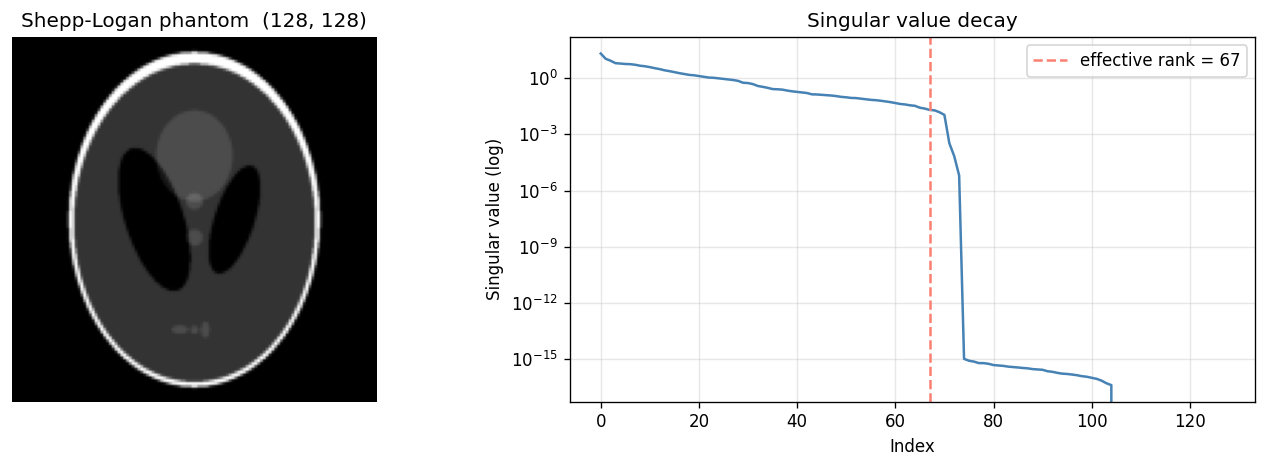

In [2]:
X_true = np.load(SHEPP_LOGAN_PATH)

sigma = np.linalg.svd(X_true, compute_uv=False)
effective_r = np.sum(sigma > sigma[0] * 1e-3)
rank = np.linalg.matrix_rank(X_true)

print(f"Image shape: {X_true.shape}")
print(f"Value range: [{X_true.min():.4f}, {X_true.max():.4f}]")
print(f"Effective rank: {effective_r} | Actual rank: {rank}")
print(f"Top 10 singular values: {np.round(sigma[:10], 3)}")
print(f"Measurements m: {N_MEASUREMENTS}")
print(f"Pixels nxn {IMAGE_SIZE**2}")
print(f"Sampling ratio: {N_MEASUREMENTS/IMAGE_SIZE**2:.4f}  ({100*N_MEASUREMENTS/IMAGE_SIZE**2:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(X_true)
axes[0].set_title(f"Shepp-Logan phantom  {X_true.shape}")
axes[0].axis('off')

axes[1].semilogy(sigma, color='steelblue', linewidth=1.5)
axes[1].axvline(x=effective_r, color='salmon', linestyle='--',
                label=f'effective rank = {effective_r}')
axes[1].set_title("Singular value decay")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Singular value (log)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
op = MeasurementOperator(n=IMAGE_SIZE, m=N_MEASUREMENTS, seed=RANDOM_SEED)
y  = op.measure(X_true)

print("Running solver...")
result = admm_solve(op, y, rho=RHO, max_iter=MAX_ITER, tol=TOL,
                    X_true=X_true, verbose=True)

Running solver...
  Iter        Primal          Dual    Rank      RelErr
-------------------------------------------------------
     1     16.640665     24.960998       0    1.000000
     2     10.883693      5.127261     107    0.856087
     3      0.943856      3.703107      89    0.730259
     4      0.702909      3.029538      80    0.691718
     5      0.603189      2.564035      76    0.658305
    51      0.010382      0.043618      50    0.367163
   101      0.000262      0.001337      50    0.362542
   151      0.000010      0.000055      50    0.362407

Converged at iteration 179
Primal residual: 1.82e-06
Dual residual: 9.87e-06
Final rank: 50
Relative error: 0.362403


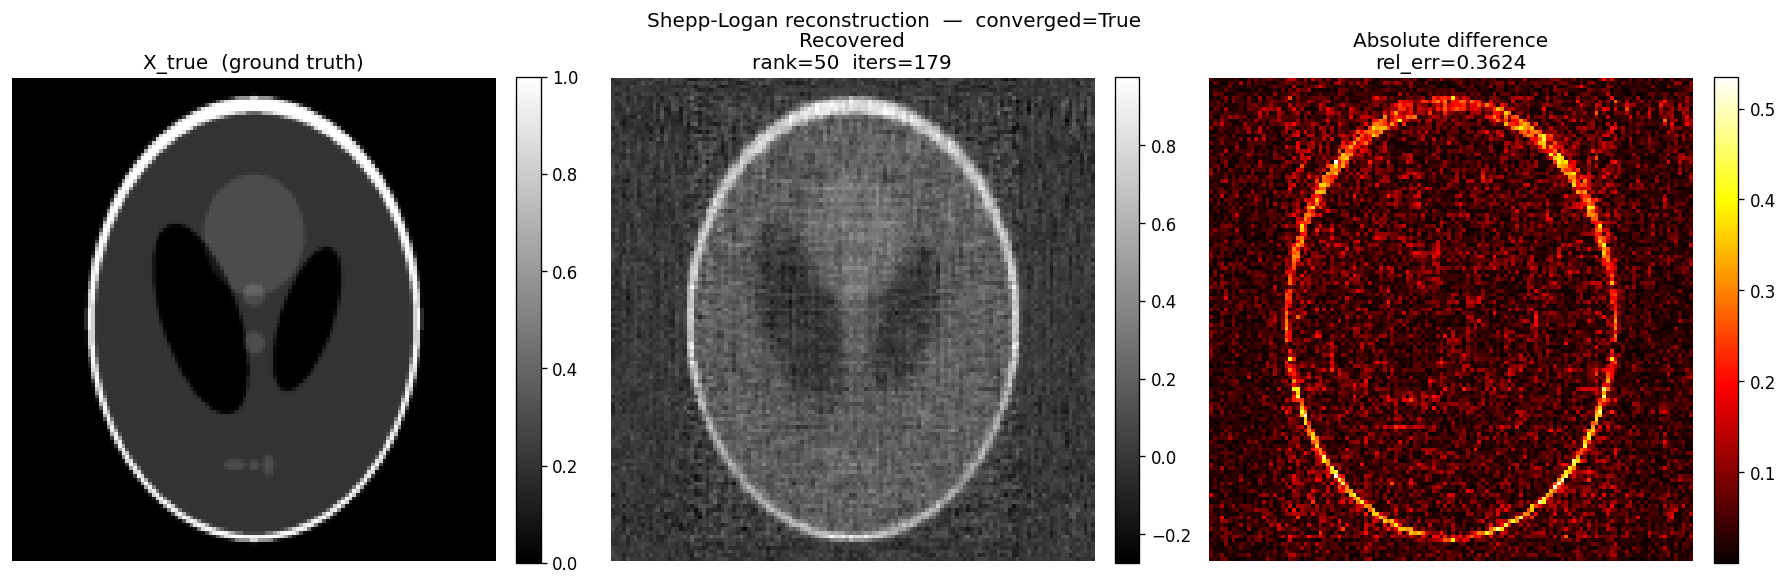

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(X_true)
axes[0].set_title("X_true  (ground truth)")
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(result.X)
axes[1].set_title(f"Recovered\nrank={effective_rank(result.X)}  "
                  f"iters={result.n_iters}")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

diff = np.abs(result.X - X_true)
rel_err = np.linalg.norm(result.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
im2 = axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f"Absolute difference\n"
                  f"rel_err={rel_err:.4f}")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"Shepp-Logan reconstruction  —  "
             f"converged={result.converged}", fontsize=12)
plt.tight_layout()
plt.show()

# Convergence plots

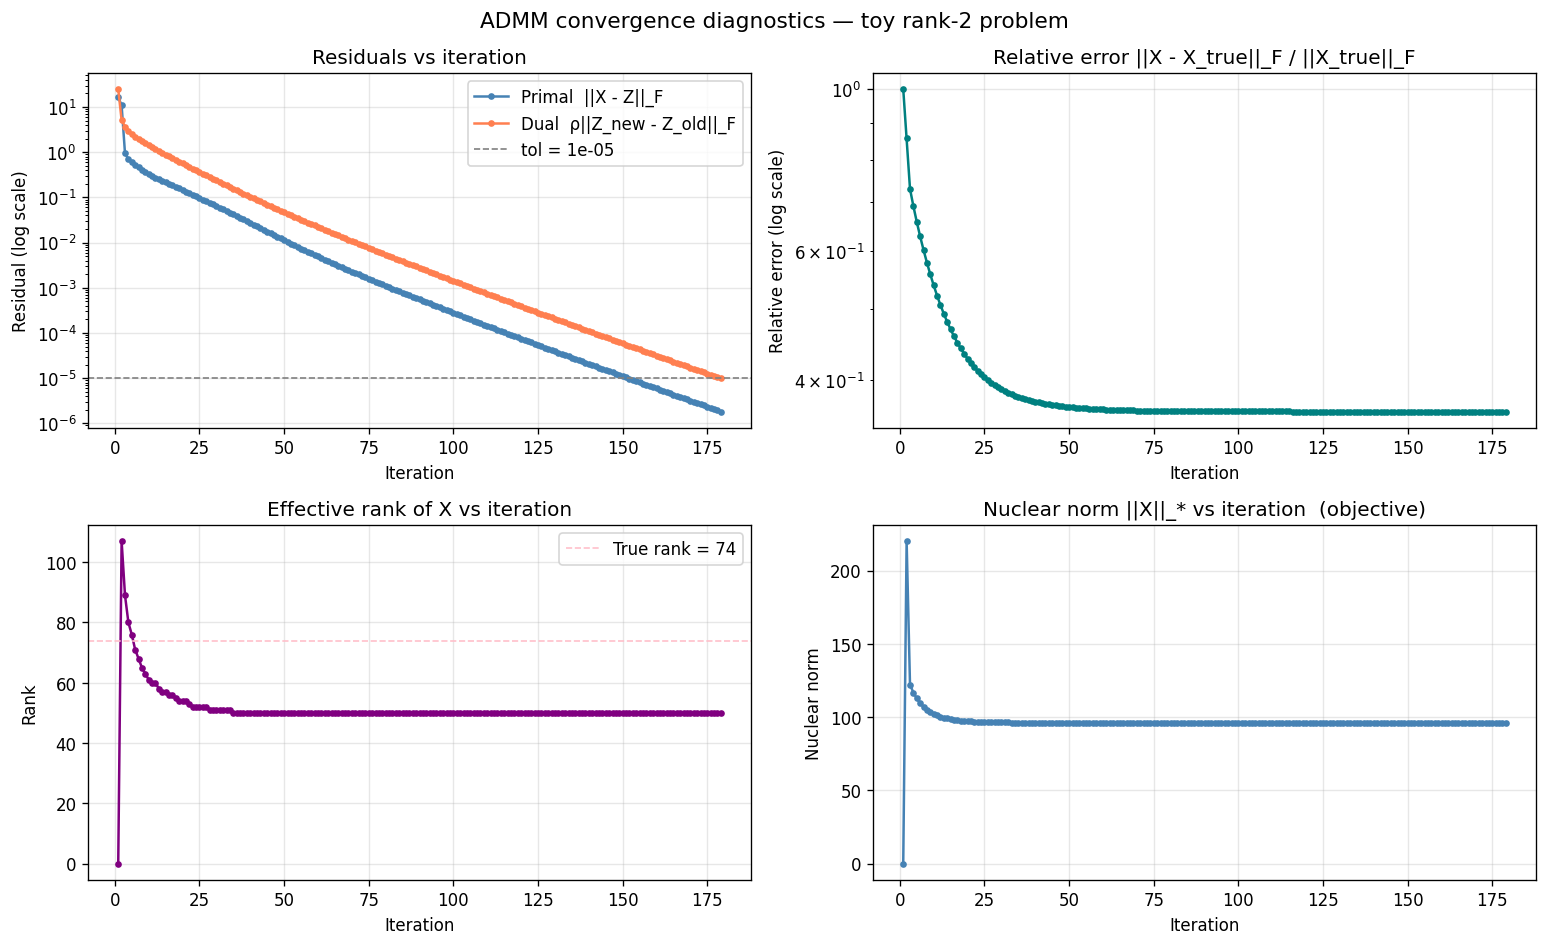

In [5]:
h = result.history
iters = range(1, result.n_iters + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Primal and dual residuals
axes[0, 0].semilogy(iters, h.primal_residuals, color='steelblue',
                    linewidth=1.5, label='Primal  ||X - Z||_F', marker='.',)
axes[0, 0].semilogy(iters, h.dual_residuals, color='coral',
                    linewidth=1.5, label='Dual  ρ||Z_new - Z_old||_F', marker='.',)
axes[0, 0].axhline(y=TOL, color='gray', linestyle='--', linewidth=1, label=f'tol = {TOL}')
axes[0, 0].set_title("Residuals vs iteration")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Residual (log scale)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Relative error vs X_true
axes[0, 1].semilogy(iters, h.rel_errors, color='teal', linewidth=1.5, marker='.')
#axes[0, 1].axhline(y=1e-2, color='gray', linestyle='--', linewidth=1, label='1% error')
axes[0, 1].set_title("Relative error ||X - X_true||_F / ||X_true||_F")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Relative error (log scale)")
#axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Rank evolution
axes[1, 0].plot(iters, h.ranks, color='purple', linewidth=1.5, marker='.',)
axes[1, 0].axhline(y=rank, color='pink', linestyle='--', linewidth=1, 
                   label=f'True rank = {rank}')
axes[1, 0].set_title("Effective rank of X vs iteration")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Rank")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Nuclear norm (objective value)
axes[1, 1].plot(iters, h.objective_values, color='steelblue', linewidth=1.5, marker='.',)
axes[1, 1].set_title("Nuclear norm ||X||_* vs iteration  (objective)")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Nuclear norm")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("ADMM convergence diagnostics — toy rank-2 problem", fontsize=13)
plt.tight_layout()
plt.show()